In [20]:
# Importing Libraries
from langgraph.graph import StateGraph, START, END
from langchain_openai import ChatOpenAI
from typing import TypedDict

from langchain_core.prompts import PromptTemplate
from langchain_core.output_parsers import StrOutputParser

from IPython.display import display, Markdown
from dotenv import load_dotenv
load_dotenv()

True

In [2]:
# Defining LLM Model
MODEL_NAME = 'gpt-4o-mini'
model = ChatOpenAI(model=MODEL_NAME)

In [3]:
# Define the state
class BlogState(TypedDict):
    title: str
    outline:str
    content: str

In [21]:
def create_outline(state:BlogState) -> BlogState:
    # Fetch the title
    title = state['title']

    # call the llm gen outline
    prompt = PromptTemplate(template="Generate a detailed outline for a blog on the topic - {title}",
                            input_variables=['title'])
    
    # Parser to fetch the output
    str_parser = StrOutputParser()
    outline_workflow = prompt | model | str_parser 

    # get the outline from LLM
    outline = outline_workflow.invoke({'title': title})

    # update the state
    state['outline'] = outline 

    return state

In [28]:
def create_blog(state:BlogState)->BlogState:

    # Fetch the title and outline from state
    title = state['title']
    outline = state['outline']

    # prepare the prompt
    prompt = PromptTemplate(template="Write a detailed blog on title - {title} using the following outline \n{outline}",
                            input_variables=['title', 'outline'])
    
    # blog workflow
    blog_workflow = prompt | model | StrOutputParser()

    # blog content 
    content = blog_workflow.invoke({
        'title': title, 'outline': outline
    })

    # update the state 
    state['content'] = content
    
    return state

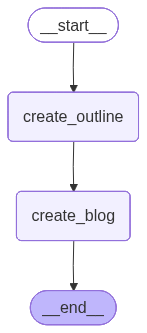

In [29]:
# Create graph
graph = StateGraph(BlogState)

# Define the nodes
graph.add_node('create_outline', create_outline)
graph.add_node('create_blog', create_blog)

# Define the edges
graph.add_edge(START, 'create_outline')
graph.add_edge('create_outline', 'create_blog')
graph.add_edge('create_blog', END)

# compile the graph
graph.compile()

In [30]:
# create the workflow
workflow = graph.compile()

# initial state
initial_state = {'title': 'Rise of AI in India'}

final_state = workflow.invoke(initial_state)

In [31]:
display(Markdown(final_state['title']))

Rise of AI in India

In [32]:
# Outline
display(Markdown(final_state['outline']))

# Outline for Blog: The Rise of AI in India

## Introduction
- Brief explanation of what AI (Artificial Intelligence) is
- Importance of AI in the modern world
- Overview of India’s evolving tech landscape and its significance in the global market

## Section 1: Historical Context
- **1.1 Early Developments in AI**
  - Origin of AI research in India
  - Key milestones in AI history in India
- **1.2 Government Involvement**
  - Initial government initiatives and policies supporting AI research 
  - Role of academic institutions in AI development

## Section 2: The Current State of AI in India
- **2.1 AI Talent Pool**
  - Growth in educational institutions and skill development programs
  - Major universities offering AI-related courses
- **2.2 Startups and Innovation**
  - Overview of AI-driven startups in India
  - Successful case studies of Indian companies leveraging AI
- **2.3 Industry Adoption**
  - Sectors adopting AI (healthcare, agriculture, finance, etc.)
  - Collaborations between traditional industries and tech companies

## Section 3: Government Initiatives and Policies
- **3.1 Policy Framework**
  - National Strategy for AI as outlined by NITI Aayog
  - The role of the Digital India program in fostering AI
- **3.2 Funding and Infrastructure**
  - Government investment in AI research and development
  - Establishment of AI research centers and innovation hubs

## Section 4: Challenges Facing AI Growth in India
- **4.1 Data Privacy and Security Concerns**
  - Discussion on data governance and the need for regulations
- **4.2 Skill Gap**
  - Addressing the mismatch between AI demand and skill availability
- **4.3 Ethical Considerations**
  - Need for ethical guidelines in AI usage
  - Challenges posed by bias in AI algorithms

## Section 5: The Future of AI in India
- **5.1 Opportunities for Growth**
  - Potential areas for AI growth in agriculture, healthcare, and smart cities
- **5.2 Global Positioning**
  - India’s place in the global AI ecosystem
  - Collaboration with international AI initiatives
- **5.3 Building a Sustainable AI Environment**
  - Promoting responsible AI development
  - Role of community engagement and education

## Section 6: Case Studies
- **6.1 Successful AI Implementations**
  - Highlight successful Indian AI applications in various sectors
  - Case studies illustrating the impact of AI on local communities
- **6.2 Lessons Learned**
  - Key takeaways from the case studies that can inform future projects

## Conclusion
- Recap of the rise of AI in India and its significance
- The importance of balancing innovation with ethical considerations and skill development
- Call to action for stakeholders (government, industry, and academia) to collaborate for sustainable AI growth

## Additional Resources
- List of further reading materials and resources on AI in India
- Links to relevant organizations and educational institutions involved in AI research

## Call for Engagement
- Encourage readers to share thoughts, experiences, or questions related to AI in India.
- Invite readers to follow the blog for updates on AI trends and developments.

In [33]:
# Blog content
display(Markdown(final_state['content']))

# The Rise of AI in India

## Introduction

Artificial Intelligence (AI) refers to the simulation of human intelligence in machines programmed to think, learn, and solve problems. It encompasses a variety of techniques and technologies, including machine learning, natural language processing, and robotics. In today's rapidly evolving digital landscape, AI plays a crucial role across multiple sectors, driving efficiencies, enhancing decision-making, and creating new market opportunities.

As one of the fastest-growing economies in the world, India's tech landscape is evolving rapidly. With its vibrant startup ecosystem, a burgeoning pool of tech talent, and a supportive governmental framework, India is well-positioned to become a global leader in AI innovation.

## Section 1: Historical Context

### 1.1 Early Developments in AI

The roots of AI research in India can be traced back to the 1980s when initial efforts were undertaken primarily through academia. Institutions like the Indian Institute of Technology (IIT) Kanpur and the Indian Institute of Science (IISc) Bangalore began exploring AI concepts, emerging as key players in the field. Early milestones included designing expert systems for different applications, laying the groundwork for subsequent research and development in AI.

### 1.2 Government Involvement

The Indian government has played a vital role in nurturing the AI ecosystem. Initiatives from organizations such as the Department of Science and Technology (DST) and the Ministry of Electronics and Information Technology (MeitY) focused on creating a supportive policy environment. Academic institutions, in partnership with government entities, have developed research grants and initiatives to foster innovation and technology transfer, enabling a more robust AI research landscape.

## Section 2: The Current State of AI in India

### 2.1 AI Talent Pool

India boasts a growing talent pool trained in AI, driven by the emergence of numerous educational programs. Major universities, including IITs and NITs, offer specialized courses in AI, machine learning, and data science, attracting thousands of students annually. Additionally, online platforms and private institutions enable continuous learning in AI and related fields, addressing the ever-evolving demands of the industry.

### 2.2 Startups and Innovation

The rise of AI-driven startups in India has significantly impacted various sectors. Companies like GreytHR, Niramai, and AIndra Systems are innovating in areas like human resource management, healthcare diagnostics, and smart farming solutions. These startups not only address local market needs but also contribute to the global AI landscape by showcasing India's innovative spirit.

### 2.3 Industry Adoption

Diverse sectors are increasingly integrating AI technologies into their operations. In healthcare, AI algorithms help in diagnostics and patient management; in agriculture, drones and smart sensors optimize crop monitoring; and in finance, algorithms enhance fraud detection and customer service. Collaborations between traditional industries and tech companies serve as a catalyst for broader AI adoption.

## Section 3: Government Initiatives and Policies

### 3.1 Policy Framework

India's strategic approach to AI is encapsulated in the National Strategy for AI developed by NITI Aayog. This policy framework envisions leveraging AI for economic growth and social empowerment while ensuring inclusive development. The Digital India program further complements this strategy by promoting digital infrastructure and skill development.

### 3.2 Funding and Infrastructure

The Indian government has committed considerable investment towards research and development in AI. Initiatives such as the National AI Portal aim to facilitate access to AI resources, while specialized research hubs and innovation centers are being established across the country to promote AI research.

## Section 4: Challenges Facing AI Growth in India

### 4.1 Data Privacy and Security Concerns

As businesses increasingly adopt AI, concerns around data privacy and governance have emerged. The need for robust regulations to protect citizens' privacy while promoting innovation is critical. Establishing clear data governance frameworks is essential for fostering trust in AI technologies.

### 4.2 Skill Gap

Despite the growth in educational programs, a significant skill gap persists between industry demands and workforce capabilities. To ensure a steady supply of qualified professionals, partnerships between academia, industry, and government must enhance practical training and academic rigor.

### 4.3 Ethical Considerations

The ethical implications of AI usage cannot be overlooked. Ensuring that AI algorithms are free from bias and that their decisions are transparent is crucial. Engaging in conversations about ethical guidelines will help mitigate societal impacts and foster responsible AI adoption.

## Section 5: The Future of AI in India

### 5.1 Opportunities for Growth

Looking forward, AI holds significant growth potential in several sectors. In agriculture, AI can help optimize resource management; in healthcare, it can aid in personalized treatment plans; and in urban planning, AI can play a crucial role in developing smart cities.

### 5.2 Global Positioning

India's rapid advancements in AI are positioning it as a key player in the global AI ecosystem. By engaging in collaborations with international research initiatives and tech giants, India can amplify its impact on global AI trends and practices.

### 5.3 Building a Sustainable AI Environment

Promoting responsible AI development is vital. This includes fostering community engagement, enhancing public awareness about AI's potential and risks, and collaborating for a sustainable AI future. Education will play a pivotal role in ensuring that future generations are well-equipped to navigate the AI landscape responsibly.

## Section 6: Case Studies

### 6.1 Successful AI Implementations

Several Indian companies are making waves with successful AI implementations. For example, Niramai has developed a revolutionary breast cancer detection method using thermography and AI, proving instrumental in saving lives. Similarly, AgroStar leverages AI algorithms to provide farmers with tailored agricultural advice, boosting yields and earnings.

### 6.2 Lessons Learned

From these case studies, several key takeaways emerge: the importance of localized solutions, the necessity for continuous innovation, and the effectiveness of public-private partnerships in fostering AI growth. Insights gained can inform future projects and improve scalability and sustainability.

## Conclusion

The rise of AI in India represents a paradigm shift with the potential to drive substantial economic and social change. Balancing innovation with ethical considerations and honing the skills of the workforce is paramount. Collaboration among stakeholders—government, industry, and academia—is necessary to foster sustainable AI growth and establish India as a global leader in AI technology.

## Additional Resources

- AI India: [AI Forum of India](https://www.aiforumindia.org)
- National Strategy for AI: [NITI Aayog PDF](https://niti.gov.in/writereaddata/files/AI-Strategy-Document.pdf)
- Online Learning: [Coursera AI Courses](https://www.coursera.org)

## Call for Engagement

We invite you to share your thoughts, experiences, or questions related to AI in India. Let’s engage in this crucial dialogue and explore the potential of AI together! Follow our blog for updates on AI trends and developments.